In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [11]:
with open(f'../pickles/mcsolve_three_outcome_state{4}_233_summed_two_level_non_partial_trace.pkl', 'rb') as file:
    result = pickle.load(file)

In [25]:
result.reconstructed_qbt_states[400]

Quantum object: dims = [[25], [25]], shape = (25, 25), type = oper, isherm = False
Qobj data =
[[ 6.93335833e-06-9.70272718e-06j -5.73492465e-04+1.00903851e-03j
  -1.68417345e-03+8.92047717e-05j  8.98127989e-06-5.12123772e-06j
   6.67225392e-06+2.61631397e-05j -9.63821451e-06+1.86197155e-05j
  -1.75948785e-05-4.60205001e-05j -7.01486932e-08-1.44858799e-05j
   6.77207176e-06+1.23081867e-05j -4.14196289e-06-1.78999131e-05j
   8.64883827e-06+1.28227416e-05j -1.23204910e-05-3.46556288e-05j
   5.98842984e-06+9.89958221e-06j  4.93374851e-07+1.31565014e-06j
  -1.46622302e-06-1.70145398e-06j  8.41977316e-07+1.25878930e-06j
   7.05332987e-07+1.04648869e-06j  1.01286129e-08+2.26196161e-07j
   5.08955903e-07-6.86330195e-07j  6.50977134e-08+3.58905279e-08j
   1.33361271e-07+3.45232081e-07j -5.86214795e-08-9.85690247e-08j
  -1.01886961e-07+1.63592741e-08j  4.49993931e-08+5.60455150e-08j
   6.99145806e-08-4.70824193e-08j]
 [ 3.51795753e-04-1.13893074e-04j -3.06538940e-01+2.92375787e-02j
  -2.5880931

In [5]:

qubit_level = 25
osc_level = 30
kappa = 1e-3

system_computational = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = qubit_level,
    osc_level = osc_level,
    kappa =kappa,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(20) ]+ \
                    [[ql, ol] for ql in [9,10,11] for ol in range(10) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )

In [6]:
import numpy as np
from qutip import Qobj
from typing import Dict, Tuple
import numpy as np
from qutip import Qobj
from typing import List, Tuple

def approximate_qubit_rho(rho: Qobj, ql: int, ol: int, product_to_dressed: Dict[Tuple[int, int], int]) -> Qobj:
    # Initialize an empty matrix to store the approximate qubit density matrix elements
    rho_q = np.zeros((ql, ql), dtype=complex)
    
    # Loop over the qubit levels p, p'
    for p in range(ql):
        for p_prime in range(ql):
            # Sum over the resonator levels n, using the mapping to get the dressed level
            sum_over_n = 0
            for n in range(ol):
                if (p, n) in product_to_dressed and (p_prime, n) in product_to_dressed:
                    dressed_index_p_n = product_to_dressed[(p, n)]
                    dressed_index_p_prime_n = product_to_dressed[(p_prime, n)]
                    # Add the contribution from this dressed state to the sum
                    sum_over_n += rho[dressed_index_p_n, dressed_index_p_prime_n]
            rho_q[p, p_prime] = sum_over_n
    
    # Return the approximate qubit density matrix as a Qobj
    return Qobj(rho_q)


In [7]:
import numpy as np
from qutip import Qobj, tensor, basis

def reconstruct_product_density_matrix(hamiltonian, max_ql: int, max_ol: int, rho_dressed: Qobj) -> Qobj:
    """
    Reconstruct the product density matrix from the dressed density matrix using squared overlaps as weights.

    Parameters:
    - hamiltonian: Hamiltonian in the product basis of the coupled qubit-resonator system.
    - ql: int, number of qubit levels.
    - ol: int, number of oscillator (resonator) levels.
    - rho_dressed: Qobj, the density matrix of the system in the dressed basis.

    Returns:
    - Qobj: The reconstructed product density matrix.
    """
    total_levels = max_ql * max_ol
    rho_product = np.zeros((total_levels, total_levels), dtype=complex)
    
    evals, evecs = hamiltonian.eigenstates()
    overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
    squared_overlaps = overlap_matrix ** 2
    # squared_overlaps[dressed_idx, product_idx] is the square overlap between the two states
    # where product_idx = max_ql * qubit_level + oscillator_level

    
    # Iterate over all elements of the product density matrix
    # for i in range(total_levels):
    #     for j in range(total_levels):
    #         # Iterate over all dressed states
    #         for k in range(total_levels):
    #             for l in range(total_levels):
    #                 rho_product[i, j] += overlap_matrix[k, i] * overlap_matrix[l, j] * rho_dressed[k, l]
    
    rho_product = np.einsum('ki,lj,kl->ij', overlap_matrix, overlap_matrix,rho_dressed, optimize=True) 

    return Qobj(rho_product, dims=[[max_ql, max_ol], [max_ql, max_ol]])


In [8]:
computational_0 = 1
computational_1 = 2
for i, system in zip([4,5],[system_computational,system_computational]):
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level_non_partial_trace.pkl', 'rb') as file:
        result = pickle.load(file)

    qbt_states = []
    two_l_states = []
    for dm in tqdm(result.states,desc=f'truncating states from result {i}'):
        qubit_rho = approximate_qubit_rho(dm,
                                        system.qbt.truncated_dim,
                                        system.osc.truncated_dim,
                                        system.product_to_dressed
                                        )
        rho_2_level = qutip.Qobj(np.array([
                        [qubit_rho[computational_0, computational_0],qubit_rho[computational_0, computational_1]],
                        [qubit_rho[computational_1, computational_0],qubit_rho[computational_1, computational_1]]
                    ]),dims=[[2],[2]])

        qbt_states.append(qubit_rho)
        two_l_states.append(rho_2_level)
    result.qbt_states = qbt_states
    result.two_l_states = two_l_states
        
    
    reconstructed_states = []
    reconstructed_qbt_states = []
    reconstructed_two_l_qbt_states = []
    for dm in tqdm(result.states,desc=f'truncating states from result {i}'):
        reconstructed_state = reconstruct_product_density_matrix(
            system_computational.hilbertspace.hamiltonian(),
            system_computational.qbt.truncated_dim,
            system_computational.osc.truncated_dim,
            dm
        )
        reconstructed_states.append(reconstructed_state)
        reconstructed_qbt_state = reconstructed_state.ptrace(0)
        reconstructed_qbt_states.append(reconstructed_qbt_state)
        rho_2_level = qutip.Qobj(np.array([
                        [reconstructed_qbt_state[computational_0, computational_0],reconstructed_qbt_state[computational_0, computational_1]],
                        [reconstructed_qbt_state[computational_1, computational_0],reconstructed_qbt_state[computational_1, computational_1]]
                    ]),dims=[[2],[2]])
        reconstructed_two_l_qbt_states.append(rho_2_level)

        result.reconstructed_states = reconstructed_states
        result.reconstructed_qbt_states = reconstructed_qbt_states
        result.reconstructed_two_l_qbt_states = reconstructed_two_l_qbt_states
        
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level_non_partial_trace.pkl', 'wb') as file:
        pickle.dump(result, file)

truncating states from result 5: 100%|██████████| 783/783 [00:00<00:00, 7490.17it/s]


processing through t_idx: 100%|██████████| 783/783 [00:08<00:00, 91.58it/s]


Text(0.5, 0, 'ns')

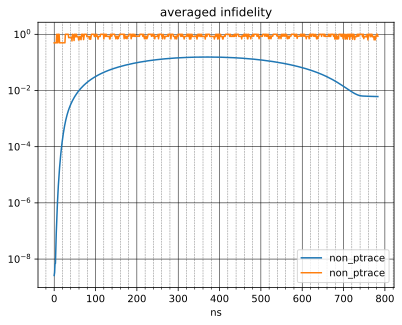

In [10]:

results = []
for i in [4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level_non_partial_trace.pkl', 'rb') as file:
        result = pickle.load(file)
    results.append(result)
num_time_steps = len(results[0].times)


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in tqdm(range(num_time_steps),desc=f'processing through t_idx'):
    dms = [result.two_l_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])
plt.plot(results[0].times,infidelity,label = 'non_ptrace')

infidelity = []
phase = []
for idx in tqdm(range(num_time_steps),desc=f'processing through t_idx'):
    dms = [result.reconstructed_two_l_qbt_states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])
plt.plot(results[0].times,infidelity,label = 'non_ptrace')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
plt.legend()
plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

processing through t_idx: 100%|██████████| 783/783 [00:12<00:00, 62.66it/s]


Text(0.5, 0, 'ns')

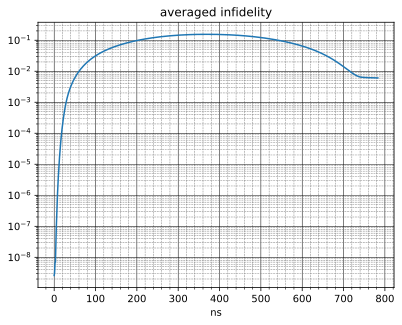

In [14]:

results_partial_trace = []
for i in [4,5]:
    with open(f'../pickles/mcsolve_three_outcome_state{i}_233_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    results_partial_trace.append(result)
num_time_steps = len(results_partial_trace[0].times)


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [(zero +  one).unit(),
                (zero - one).unit(), ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        # fid.append(qutip.fidelity(new_dm, dm_ideal))
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in tqdm(range(num_time_steps),desc=f'processing through t_idx'):
    dms = [result.states[idx] for result in results_partial_trace]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])


plt.plot(results_partial_trace[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

In [28]:
idx = 300
results[0].two_l_states[idx]

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.49999581+0.j         0.2299034 -0.00571715j]
 [0.2299034 +0.00571715j 0.50000405+0.j        ]]

In [29]:
results_partial_trace[0].states[idx]

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.49999581+0.j         0.2299034 -0.00571715j]
 [0.2299034 +0.00571715j 0.50000405+0.j        ]]